<a href="https://colab.research.google.com/github/fidanzeyneddin/goruntu-isleme/blob/main/goruntu_isleme.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%bash
# 1. Önceden derlenmiş OpenCV + CUDA arşivini indir (65 MB)
gdown "1qqkBs9lI7q--4AwHj9SNhVJOTXNk-DzP" -O /content/opencv_cuda_t4.tar.gz

# 2. Arşivi /content dizinine aç
tar -xzf /content/opencv_cuda_t4.tar.gz -C /content

# 3. Kurulum ve CUDA testi
cat << 'EOF' > test_env.cpp
#include <iostream>
#include <opencv2/core.hpp>
#include <opencv2/core/cuda.hpp>

int main() {
    std::cout << "OpenCV Surumu: " << CV_VERSION << std::endl;
    int count = cv::cuda::getCudaEnabledDeviceCount();
    std::cout << "CUDA Destekli GPU Sayisi: " << count << std::endl;
    if (count > 0) {
        cv::cuda::printShortCudaDeviceInfo(cv::cuda::getDevice());
    }
    return 0;
}
EOF

# Derle ve Çalıştır
g++ -std=c++17 test_env.cpp -o test_env \
    -I/content/opencv_install/include/opencv4 \
    -L/content/opencv_install/lib \
    -lopencv_core -lopencv_cudaarithm \
    -Wl,-rpath,/content/opencv_install/lib

./test_env

OpenCV Surumu: 4.10.0
CUDA Destekli GPU Sayisi: 1
Device 0:  "Tesla T4"  14913Mb, sm_75, Driver/Runtime ver.13.0/12.80


Downloading...
From (original): https://drive.google.com/uc?id=1qqkBs9lI7q--4AwHj9SNhVJOTXNk-DzP
From (redirected): https://drive.google.com/uc?id=1qqkBs9lI7q--4AwHj9SNhVJOTXNk-DzP&confirm=t&uuid=89291c0d-34bd-4905-9b79-1bbf9702a0e1
To: /content/opencv_cuda_t4.tar.gz
100%|██████████| 65.0M/65.0M [00:00<00:00, 211MB/s]


In [2]:
!mkdir -p girdi_resimleri
!mkdir -p cikti_resimleri
!wget -q -O girdi_resimleri/ornek1.jpg "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"

In [3]:
%%writefile resize.cpp
#include <iostream>
#include <vector>
#include <string>
#include <opencv2/opencv.hpp>

int main() {
    // İşlenecek ve kaydedilecek klasör yolları
    std::string girdi_klasoru = "girdi_resimleri/*.jpg";
    std::string cikti_klasoru = "cikti_resimleri/";

    std::vector<cv::String> dosya_isimleri;

    // cv::glob ile klasördeki tüm eşleşen dosyaları buluyoruz
    cv::glob(girdi_klasoru, dosya_isimleri, false);

    if (dosya_isimleri.empty()) {
        std::cout << "Klasörde işlenecek resim bulunamadı!" << std::endl;
        return -1;
    }

    // Bulunan her bir resim için döngü başlatıyoruz
    for (size_t i = 0; i < dosya_isimleri.size(); ++i) {
        // 1. Resmi Oku
        cv::Mat resim = cv::imread(dosya_isimleri[i]);
        if (resim.empty()) continue;

        // 2. Resmi 1024x768 boyutuna ölçekle
        cv::Mat yeniden_boyutlandirilmis;
        cv::resize(resim, yeniden_boyutlandirilmis, cv::Size(1024, 768));

        // Dosya yolundan sadece dosya adını ayıklama (örnek1.jpg gibi)
        size_t son_slash_index = dosya_isimleri[i].find_last_of("\\/");
        std::string dosya_adi = dosya_isimleri[i].substr(son_slash_index + 1);

        // 3. Yeni resmi çıktı klasörüne kaydet
        std::string kayit_yolu = cikti_klasoru + "yeni_" + dosya_adi;
        cv::imwrite(kayit_yolu, yeniden_boyutlandirilmis);

        std::cout << dosya_adi << " basariyla 1024x768 yapildi ve kaydedildi." << std::endl;
    }

    return 0;
}

Writing resize.cpp


In [4]:
!g++ -std=c++17 resize.cpp -o resize \
-I/content/opencv_install/include/opencv4 \
-L/content/opencv_install/lib \
-lopencv_core -lopencv_imgproc -lopencv_imgcodecs \
-Wl,-rpath,/content/opencv_install/lib

!./resize

0ccbb0c34e602cfe3fe958ba7b0950b6.jpg basariyla 1024x768 yapildi ve kaydedildi.
2c4e2ea1ef512a7416c2eb3f554e8f3b.jpg basariyla 1024x768 yapildi ve kaydedildi.
80f78d096d1cc780f95b1ca6a4f00451.jpg basariyla 1024x768 yapildi ve kaydedildi.
cb89dde2bc82ee72ed23d3ba0d88a6cb.jpg basariyla 1024x768 yapildi ve kaydedildi.
d12cf966ea4756fe5801a3a9869c2e95.jpg basariyla 1024x768 yapildi ve kaydedildi.
ornek1.jpg basariyla 1024x768 yapildi ve kaydedildi.


2.HAFTA

In [5]:
%%writefile quantize.cpp
#include <iostream>
#include <opencv2/opencv.hpp>

int main() {
    // 1. Resmi gri tonlamalı (tek kanallı) olarak oku
    // Lütfen buradaki "hoca_resim.jpg" kısmını yüklediğin dosyanın adıyla değiştir.
    cv::Mat img = cv::imread("hoca_resim.jpg", cv::IMREAD_GRAYSCALE);

    if (img.empty()) {
        std::cout << "Resim okunamadi! Dosya adini ve yolunu kontrol edin." << std::endl;
        return -1;
    }

    // 2. 8-Bit -> 6-Bit Nicemleme İşlemi
    // 8 bit (256 ton) -> 6 bit (64 ton) düşürmek için 256/64 = 4.
    // Pikselleri 4'e bölüp tekrar 4'e çarparak aradaki ton detaylarını siliyoruz.
    cv::Mat quantized_img = (img / 4) * 4;

    // 3. Sonucu kaydet
    cv::imwrite("nicemlenmis_6bit.jpg", quantized_img);

    std::cout << "8-Bit'ten 6-Bit'e nicemleme islemi basariyla tamamlandi!" << std::endl;
    return 0;
}

Writing quantize.cpp


In [6]:
!g++ -std=c++17 quantize.cpp -o quantize \
-I/content/opencv_install/include/opencv4 \
-L/content/opencv_install/lib \
-lopencv_core -lopencv_imgproc -lopencv_imgcodecs \
-Wl,-rpath,/content/opencv_install/lib

!./quantize

8-Bit'ten 6-Bit'e nicemleme islemi basariyla tamamlandi!


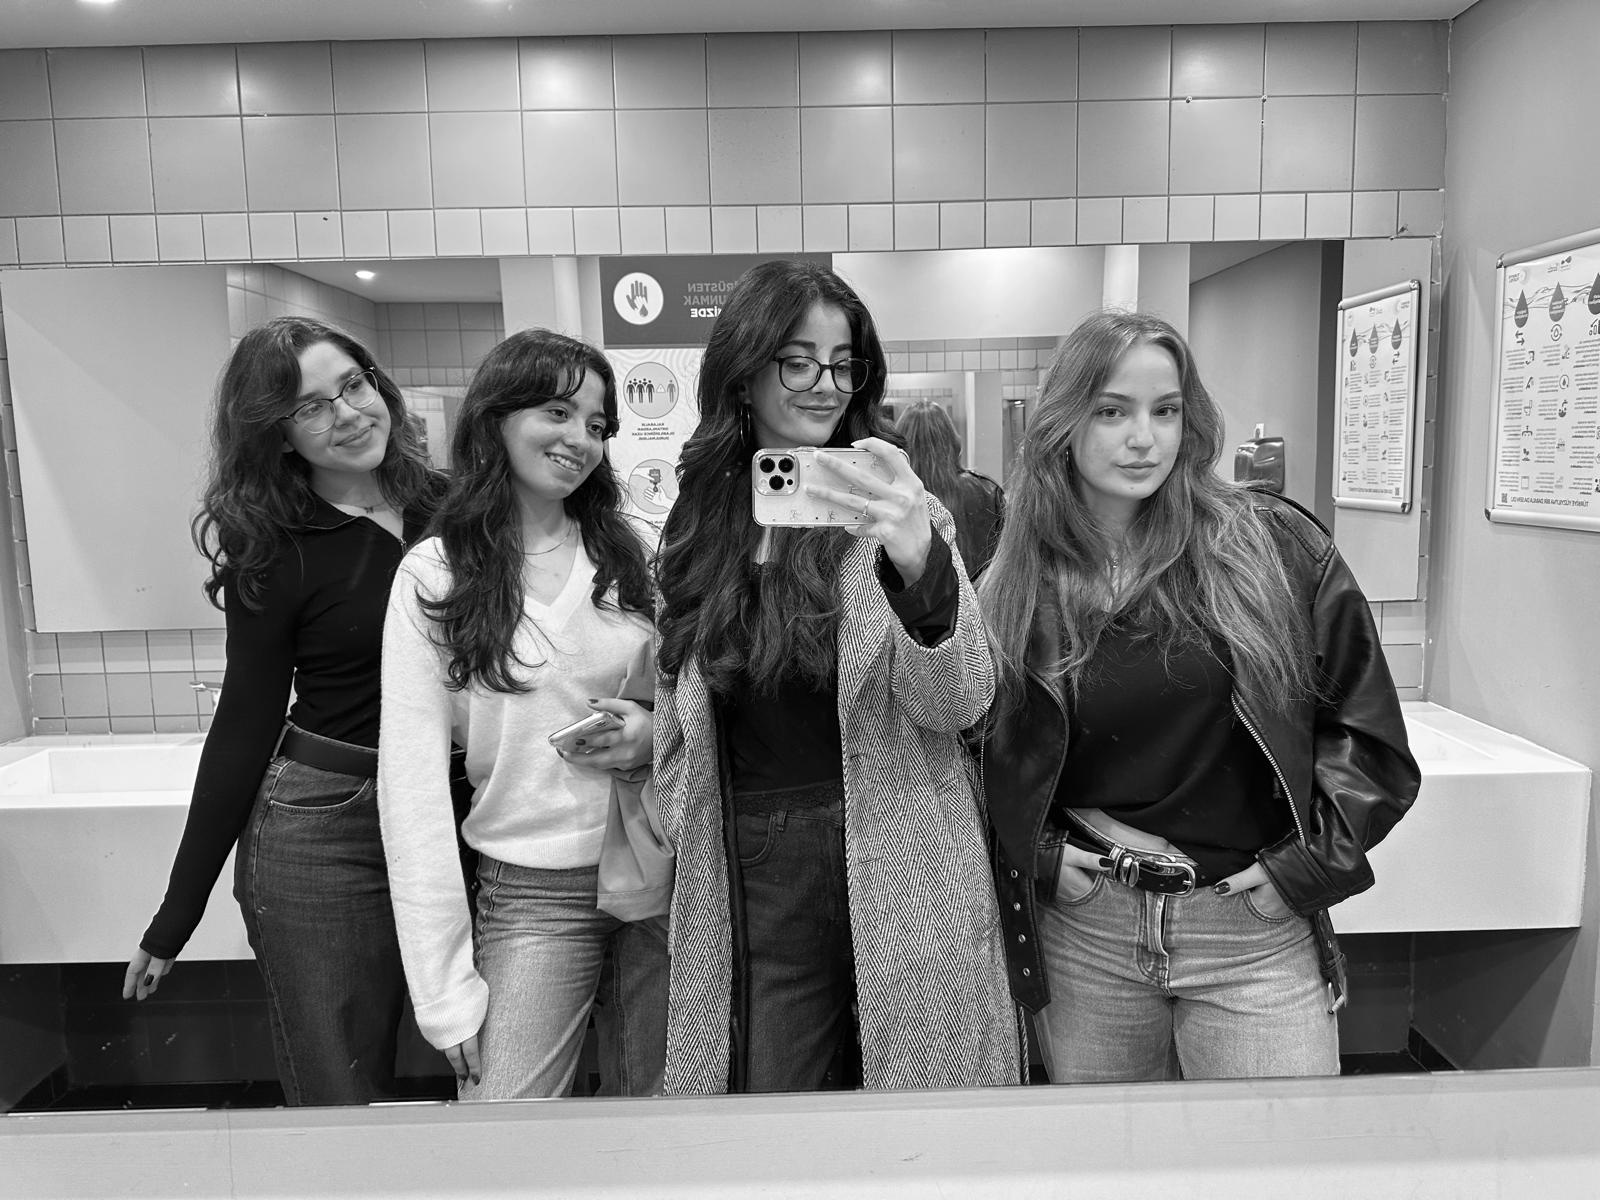

In [7]:
import cv2
from google.colab.patches import cv2_imshow

# C++ ile oluşturduğumuz 6-bit resmi okuyup hücre altına yazdırıyoruz
gosterilecek_resim = cv2.imread('nicemlenmis_6bit.jpg')
cv2_imshow(gosterilecek_resim)

In [8]:
%%writefile threads_brightness.cpp
#include <iostream>
#include <opencv2/opencv.hpp>
#include <thread>
#include <vector>
#include <chrono>

using namespace std;
using namespace cv;
using namespace std::chrono;

// Belirli bir satır aralığındaki piksellerin parlaklığını değiştiren fonksiyon
void changeBrightness(const Mat& src, Mat& dst, int start_row, int end_row, int beta) {
    for (int y = start_row; y < end_row; ++y) {
        const uchar* src_row = src.ptr<uchar>(y);
        uchar* dst_row = dst.ptr<uchar>(y);
        for (int x = 0; x < src.cols; ++x) {
            // cv::saturate_cast, piksel değerinin taşmasını önler (0-255 arasında tutar)
            dst_row[x] = saturate_cast<uchar>(src_row[x] + beta);
        }
    }
}

int main() {
    // 1. Resmi gri tonlamalı oku (tek kanallı)
    Mat img = imread("hoca_resim.jpg", IMREAD_GRAYSCALE);
    if (img.empty()) {
        cout << "Resim okunamadi! Lutfen dosya adini kontrol edin." << endl;
        return -1;
    }

    // İşlem yapılacak hedef matrisleri orijinal resmin kopyası olarak oluştur
    Mat dst_1thread = img.clone();
    Mat dst_4thread = img.clone();

    int rows = img.rows;
    int step = rows / 4; // Görüntüyü yatay 4 parçaya bölmek için adım boyutu

    // 4 parça için 4 farklı parlaklık artış değeri
    vector<int> betas = {20, 40, 60, 80};

    // ==========================================
    // 1 THREAD İLE İŞLEM (Sıralı)
    // ==========================================
    auto start_1 = high_resolution_clock::now();

    for(int i = 0; i < 4; ++i) {
        int start_r = i * step;
        int end_r = (i == 3) ? rows : (i + 1) * step; // Son parça kalanı da alsın
        changeBrightness(img, dst_1thread, start_r, end_r, betas[i]);
    }

    auto end_1 = high_resolution_clock::now();
    auto duration_1 = duration_cast<milliseconds>(end_1 - start_1).count();

    // ==========================================
    // 4 THREAD İLE İŞLEM (Paralel)
    // ==========================================
    auto start_4 = high_resolution_clock::now();

    vector<thread> threads;
    for (int i = 0; i < 4; ++i) {
        int start_r = i * step;
        int end_r = (i == 3) ? rows : (i + 1) * step;

        // 4 ayrı iş parçacığını başlat (matrisleri referans olarak gönderiyoruz)
        threads.emplace_back(changeBrightness, ref(img), ref(dst_4thread), start_r, end_r, betas[i]);
    }

    // Bütün thread'lerin işini bitirmesini bekle
    for (auto& t : threads) {
        t.join();
    }

    auto end_4 = high_resolution_clock::now();
    auto duration_4 = duration_cast<milliseconds>(end_4 - start_4).count();

    // ==========================================
    // SONUÇLARI YAZDIR VE KAYDET
    // ==========================================
    cout << "--- Sure Karsilastirmasi ---" << endl;
    cout << "1 Thread (Sirali) islem suresi : " << duration_1 << " ms" << endl;
    cout << "4 Thread (Paralel) islem suresi: " << duration_4 << " ms" << endl;

    imwrite("sonuc_4thread.jpg", dst_4thread);

    return 0;
}

Writing threads_brightness.cpp


In [9]:
!g++ -std=c++17 threads_brightness.cpp -o threads_brightness \
-I/content/opencv_install/include/opencv4 \
-L/content/opencv_install/lib \
-lopencv_core -lopencv_imgproc -lopencv_imgcodecs -pthread \
-Wl,-rpath,/content/opencv_install/lib

!./threads_brightness

--- Sure Karsilastirmasi ---
1 Thread (Sirali) islem suresi : 8 ms
4 Thread (Paralel) islem suresi: 8 ms


4 Parçaya Bölünmüş ve Parlaklıkları (+20, +40, +60, +80) Artırılmış Resim:


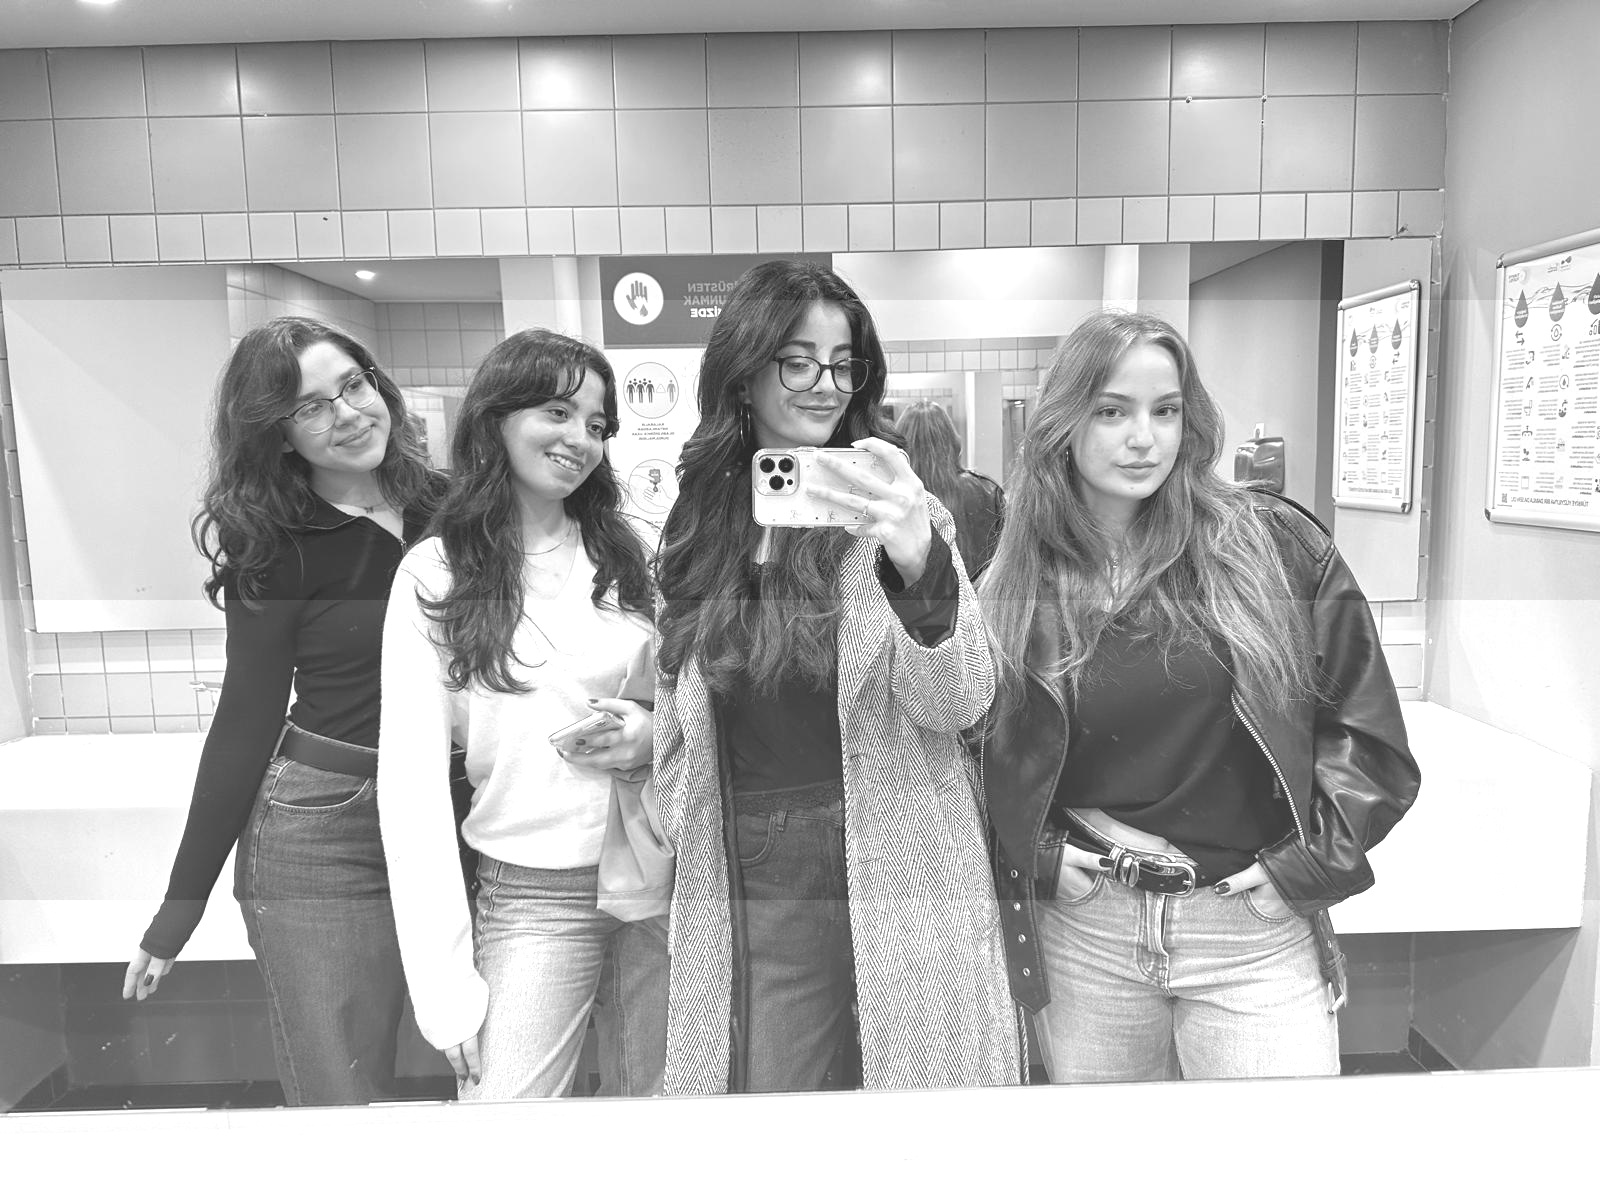

In [10]:
import cv2
from google.colab.patches import cv2_imshow

sonuc_resmi = cv2.imread('sonuc_4thread.jpg')
print("4 Parçaya Bölünmüş ve Parlaklıkları (+20, +40, +60, +80) Artırılmış Resim:")
cv2_imshow(sonuc_resmi)

In [11]:
%%writefile threads_histogram.cpp
#include <iostream>
#include <opencv2/opencv.hpp>
#include <thread>
#include <vector>
#include <chrono>

using namespace std;
using namespace cv;
using namespace std::chrono;

// Her bir iş parçacığının (thread) kendi bölgesindeki histogramı hesaplaması için fonksiyon
void calculateHistogram(const Mat& src, int start_row, int end_row, vector<int>& local_hist) {
    // local_hist dizisini sıfırla (256 elemanlı)
    fill(local_hist.begin(), local_hist.end(), 0);

    for (int y = start_row; y < end_row; ++y) {
        const uchar* row_ptr = src.ptr<uchar>(y);
        for (int x = 0; x < src.cols; ++x) {
            // Pikselin parlaklık değerine (0-255) karşılık gelen indeksi 1 artır
            local_hist[row_ptr[x]]++;
        }
    }
}

int main() {
    // 1. Resmi gri tonlamalı oku (tek kanallı)
    Mat img = imread("hoca_resim.jpg", IMREAD_GRAYSCALE);
    if (img.empty()) {
        cout << "Resim okunamadi! Lutfen dosya adini kontrol edin." << endl;
        return -1;
    }

    int rows = img.rows;
    int step = rows / 4;

    // ==========================================
    // 1 THREAD İLE HİSTOGRAM HESAPLAMA (Sıralı)
    // ==========================================
    vector<int> hist_1thread(256, 0); // 256 elemanlı sıfırlarla dolu liste
    auto start_1 = high_resolution_clock::now();

    // Tek seferde tüm satırları (0'dan rows'a kadar) hesapla
    calculateHistogram(img, 0, rows, hist_1thread);

    auto end_1 = high_resolution_clock::now();
    auto duration_1 = duration_cast<milliseconds>(end_1 - start_1).count();

    // ==========================================
    // 4 THREAD İLE HİSTOGRAM HESAPLAMA VE BİRLEŞTİRME
    // ==========================================
    // Her thread'in kendi hesaplayacağı 4 ayrı alt histogram
    vector<vector<int>> local_hists(4, vector<int>(256, 0));
    vector<int> hist_4thread_merged(256, 0); // Birleştirilecek ana histogram

    auto start_4 = high_resolution_clock::now();

    vector<thread> threads;
    for (int i = 0; i < 4; ++i) {
        int start_r = i * step;
        int end_r = (i == 3) ? rows : (i + 1) * step;
        // Her thread'e kendi start_r, end_r değerini ve kendi histogram dizisini gönderiyoruz
        threads.emplace_back(calculateHistogram, ref(img), start_r, end_r, ref(local_hists[i]));
    }

    // Bütün thread'lerin işini bitirmesini bekle
    for (auto& t : threads) {
        t.join();
    }

    // 4 Parçanın Histogramlarını Tek Bir Ana Histogramda Birleştirme
    for (int i = 0; i < 4; ++i) {
        for (int j = 0; j < 256; ++j) {
            hist_4thread_merged[j] += local_hists[i][j];
        }
    }

    auto end_4 = high_resolution_clock::now();
    auto duration_4 = duration_cast<milliseconds>(end_4 - start_4).count();

    // ==========================================
    // SONUÇLARI YAZDIR
    // ==========================================
    cout << "--- Histogram Sure Karsilastirmasi ---" << endl;
    cout << "1 Thread (Sirali) islem suresi : " << duration_1 << " ms" << endl;
    cout << "4 Thread (Paralel) islem suresi: " << duration_4 << " ms" << endl;

    // Hesabın doğru yapıldığını kanıtlamak için 128 tonuna sahip piksel sayısını karşılaştıralım
    cout << "\nDogrulama Testi (Ton 128 Piksel Sayisi):" << endl;
    cout << "1 Thread Sonucu    : " << hist_1thread[128] << endl;
    cout << "4 Thread Birlesik  : " << hist_4thread_merged[128] << endl;

    if(hist_1thread[128] == hist_4thread_merged[128]) {
        cout << "Harika! Sonuclar eslesiyor, birlestirme basarili." << endl;
    }

    return 0;
}

Writing threads_histogram.cpp


In [12]:
!g++ -std=c++17 threads_histogram.cpp -o threads_histogram \
-I/content/opencv_install/include/opencv4 \
-L/content/opencv_install/lib \
-lopencv_core -lopencv_imgproc -lopencv_imgcodecs -pthread \
-Wl,-rpath,/content/opencv_install/lib

!./threads_histogram

--- Histogram Sure Karsilastirmasi ---
1 Thread (Sirali) islem suresi : 7 ms
4 Thread (Paralel) islem suresi: 8 ms

Dogrulama Testi (Ton 128 Piksel Sayisi):
1 Thread Sonucu    : 7332
4 Thread Birlesik  : 7332
Harika! Sonuclar eslesiyor, birlestirme basarili.


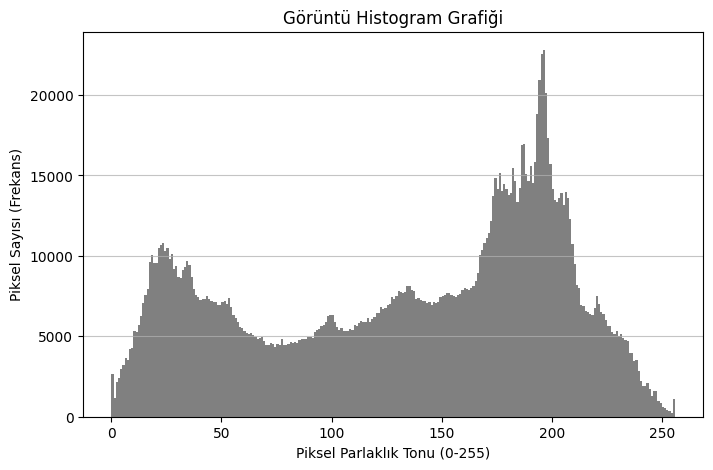

In [13]:
import cv2
import matplotlib.pyplot as plt

# Resmi gri tonlamalı oku
img = cv2.imread('hoca_resim.jpg', cv2.IMREAD_GRAYSCALE)

# Histogram grafiğini çiz
plt.figure(figsize=(8, 5))
plt.hist(img.ravel(), bins=256, range=[0,256], color='gray')
plt.title('Görüntü Histogram Grafiği')
plt.xlabel('Piksel Parlaklık Tonu (0-255)')
plt.ylabel('Piksel Sayısı (Frekans)')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [14]:
%%writefile linear_transform.cpp
#include <iostream>
#include <opencv2/opencv.hpp>

using namespace std;
using namespace cv;

int main() {
    // Resmi gri tonlamalı oku
    Mat img = imread("hoca_resim.jpg", IMREAD_GRAYSCALE);
    if (img.empty()) {
        cout << "Resim okunamadi! Lutfen dosya adini kontrol edin." << endl;
        return -1;
    }

    Mat sadece_carpim, carpim_ve_toplam;

    // 1. İşlem: Sadece 0.75 ile çarp (alpha=0.75, beta=0)
    img.convertTo(sadece_carpim, -1, 0.75, 0);

    // 2. İşlem: 0.75 ile çarp ve 20 ekle (alpha=0.75, beta=20)
    img.convertTo(carpim_ve_toplam, -1, 0.75, 20);

    // Sonuçları kaydet
    imwrite("islem1_sadece_075.jpg", sadece_carpim);
    imwrite("islem2_075_arti_20.jpg", carpim_ve_toplam);

    cout << "Lineer donusum islemleri basariyla tamamlandi ve kaydedildi!" << endl;
    return 0;
}

Writing linear_transform.cpp


In [15]:
!g++ -std=c++17 linear_transform.cpp -o linear_transform \
-I/content/opencv_install/include/opencv4 \
-L/content/opencv_install/lib \
-lopencv_core -lopencv_imgproc -lopencv_imgcodecs \
-Wl,-rpath,/content/opencv_install/lib

!./linear_transform

Lineer donusum islemleri basariyla tamamlandi ve kaydedildi!


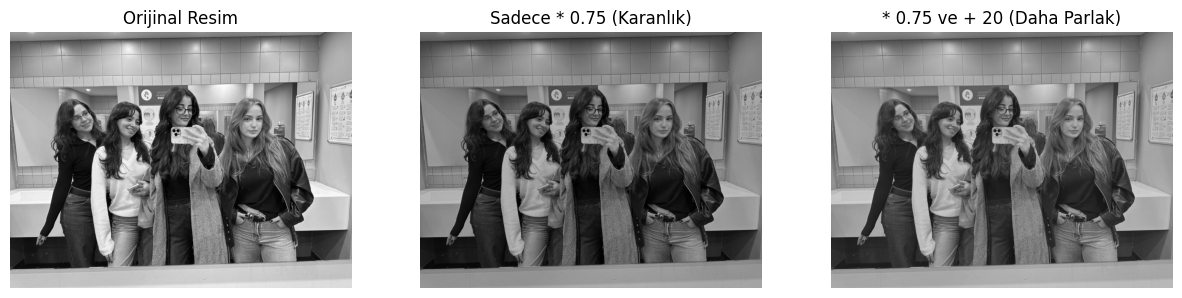

In [16]:
import cv2
import matplotlib.pyplot as plt

orijinal = cv2.imread('hoca_resim.jpg', cv2.IMREAD_GRAYSCALE)
islem1 = cv2.imread('islem1_sadece_075.jpg', cv2.IMREAD_GRAYSCALE)
islem2 = cv2.imread('islem2_075_arti_20.jpg', cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(orijinal, cmap='gray', vmin=0, vmax=255)
plt.title('Orijinal Resim')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(islem1, cmap='gray', vmin=0, vmax=255)
plt.title('Sadece * 0.75 (Karanlık)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(islem2, cmap='gray', vmin=0, vmax=255)
plt.title('* 0.75 ve + 20 (Daha Parlak)')
plt.axis('off')

plt.show()